In [46]:
%reload_ext autoreload
%autoreload 2

In [47]:
# from kret_studies import *
# from kret_studies.notebook import *
# from kret_studies.complex import *

# logger = get_notebook_logger()

In [48]:
from waymo_agent import *
from waymo_agent.osmnx import *
from waymo_agent.data_classes import *
from waymo_agent.action_heuristic import *
from waymo_agent.graph_env import *
from waymo_agent.simulation import *
from kret_sandbox.VIS import dtt

In [49]:
config = EnvConfig(max_new_requests_per_step=2, lambda_per_node=0.5)
plt_cfg = PlotConfig()

In [50]:
env = RideShareEnv(config, plt_cfg)
G = env.G
cfg = env.config

Assigned lambda values to nodes. Total lambda: 379.2269 (target: 391.0000)


/Users/Akseldkw/micromamba/envs/kret_312/lib/python3.12/site-packages/gymnasium/spaces/box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/Users/Akseldkw/micromamba/envs/kret_312/lib/python3.12/site-packages/gymnasium/spaces/box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


In [51]:
s, info = env.reset()

In [52]:
def get_obvs_tuple(env: RideShareEnv):
    veh = env.observation_curr["vehicles"]
    req = env.observation_curr["pending_requests"]
    rides = env.observation_curr["active_rides"]
    return veh, req, rides

In [53]:
veh, req, rides = get_obvs_tuple(env)
veh.shape, req.shape, rides.shape

((2, 6), (25, 21), (2, 18))

In [54]:
action = env.action_space.sample()
dispatches = pd.DataFrame({"dispatch": action["dispatch"]})
prices = pd.DataFrame({"prices": action["prices"]})
reposition = pd.DataFrame(action["reposition"], columns=["x", "y"])
action["dispatch"] = np.full(action["dispatch"].shape, cfg.no_action_id, dtype=np.int32)
action["reposition"] = np.array([[-0.1, -0.1], [0.1, 0.1]], dtype=np.float32)
env.action_space.contains(action)

True

## Pre-Step

In [55]:
# env.config.max_new_requests_per_step = 0

In [293]:
action["dispatch"][2] = 0
action["dispatch"][3] = 1
# action["dispatch"] = np.full(action["dispatch"].shape, cfg.no_action_id, dtype=np.int32)
env._validate_action(action)
action["dispatch"]

array([-1, -1,  0,  1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1], dtype=int32)

In [294]:
dtt([req[req.f_valid], veh, rides], n=12, how="head")

,request_id,request_dt,cust_id,cust_bias,cust_temperature,est_cost,price,max_wait_time,wait_time,status,pickup_node_id,pickup_x_norm,pickup_y_norm,dropoff_node_id,dropoff_x_norm,dropoff_y_norm,route_nodes,curr_start_node,curr_end_node,route_dist_on_edge,distance_meters
0,6265,2025-01-03 02:47:25.776316,1043,-0.214,1.628,7.399,NaN,0 days 00:15:00,0 days 00:00:00,0,42453952,-0.469,-0.662,13208007103,-0.039,0.280,"[42453952, 42429562, 42445356, 42445357, 42424610, 42424408, 4142105822, 12417264049, 42436374, 42432214, 42435624, 42435644, 42435646, 42435650, 42435663, 42432700, 42435675, 42432589, 42435684, 42435705, 42435707, 42435714, 1825841704, 1825841655, 42428575, 42428588, 13208007103]",42453952,42429562,0.0,7399.144
1,6369,2025-01-03 02:47:25.776316,25467,1.170,1.996,6.433,NaN,0 days 00:15:00,0 days 00:00:00,0,9166033062,-0.104,-0.512,42447228,0.154,0.214,"[9166033062, 42439006, 42440743, 42448707, 42445417, 42445390, 42422899, 12154055788, 42455929, 42442937, 42442947, 42434090, 42438894, 42442952, 42436710, 42442957, 42432861, 6680686985, 9177540204, 42449971, 4288677093, 6177439759, 42447020, 42447060, 42455666, 596776032, 42445972, 42445976, 42447228]",9166033062,42439006,0.0,6433.065
2,5808,2025-01-03 02:45:25.776316,19393,0.819,2.285,0.632,0.321,0 days 00:15:00,0 days 00:02:00,1,486868873,-0.170,-0.558,1918039877,-0.179,-0.491,"[486868873, 7480301864, 1918039877]",486868873,7480301864,0.0,632.007
3,5641,2025-01-03 02:45:25.776316,19259,1.222,1.577,11.608,1.574,0 days 00:15:00,0 days 00:02:00,1,42421745,0.182,0.726,278609934,-0.343,-0.710,"[42421745, 42428714, 42428711, 42428674, 42428653, 42428634, 9177424867, 42428595, 9915469771, 42428588, 42428575, 1825841655, 1825841704, 42435714, 42435707, 42435705, 42435684, 42432589, 42435675, 42432700, 42435663, 42435650, 42435646, 42435644, 42435624, 42432214, 42430828, 42430761, 42445574, 42423456, 42440838, 3788379733, 4143859873, 42440829, 42428433, 5706569898, 42430535, 12554607194, 4158740807, 278642478, 278609934]",42421745,42428714,0.0,11607.891
4,5483,2025-01-03 02:44:25.776316,12575,2.769,1.514,1.560,0.321,0 days 00:15:00,0 days 00:03:00,1,42445365,-0.052,-0.113,42442947,0.138,-0.051,"[42445365, 561042190, 3786901743, 42445374, 42445378, 42445382, 42434962, 42434965, 42423020, 42442918, 42442937, 42442947]",42445365,561042190,0.0,1560.411
5,5179,2025-01-03 02:43:25.776316,23870,1.173,1.236,2.219,0.321,0 days 00:15:00,0 days 00:04:00,1,42431626,-0.518,-0.592,4147546533,-0.483,-0.830,"[42431626, 42429570, 42453398, 4149748671, 588593059, 3574648569, 246911576, 42451370, 42451375, 246923513, 1772136801, 3914862593, 588546891, 42426747, 370880739, 4147546533]",42431626,42429570,0.0,2218.511
6,5027,2025-01-03 02:42:25.776316,44521,3.622,1.513,10.989,0.321,0 days 00:15:00,0 days 00:05:00,1,42458435,0.045,0.637,42427335,-0.072,-0.622,"[42458435, 42422399, 7912855687, 42422592, 42428653, 42428634, 9177424867, 42428595, 9915469771, 42428588, 42428575, 1825841655, 1825841704, 42435714, 42435707, 42435705, 42435684, 42432589, 42435675, 42432700, 42435663, 42435650, 42435646, 42435644, 42435624, 42432214, 42430828, 42430237, 4321748237, 4202908174, 42428447, 42445511, 42437612, 1918039864, 42429752, 1773076513, 42437589, 42452067, 42437996, 42437962, 42451593, 5804835269, 42427335]",42458435,42422399,0.0,10989.210
7,4946,2025-01-03 02:42:25.776316,18828,2.071,2.272,4.832,1.574,0 days 00:15:00,0 days 00:05:00,1,42434085,0.085,-0.015,246649427,-0.477,-0.258,"[42434085, 100522741, 596775840, 42434074, 42434072, 42430347, 42430344, 42428297, 42432700, 42432703, 42437368, 42445001, 4491359481, 42444964, 427842070, 9971300853, 42434427, 42437670, 1701844618, 42437693, 42437914, 42445766, 246648219, 42454328, 246649429, 246649427]",42434085,100522741,0.0,4831.625
8,4818,2025-01-03 02:41:25.776316,41138,3.412,1.830,10.751,1.574,0 days 00:15:00,0 days 00:06:00,1,596776654,0.633,0.785,42432165,-0.291,-0.531,"[596776654, 596776201, 7076060066, 596776260, 596776164, 596776089, 596776057, 5

In [295]:
dtt([env.breadcrumbs, env.DiscardedRequests])

step 
 timestamp 
 error_msg 
 rewards 
 supply_demand_ratio 
 
 
 
 
 4 
 4 
 2025-01-03 02:33:25.776316 
 
 -0.821 
 0.000 
 
 
 11 
 11 
 2025-01-03 02:40:25.776316 
 
 -0.922 
 0.378 
 
 
 14 
 14 
 2025-01-03 02:43:25.776316 
 
 0.300 
 0.269 
 
 
 16 
 16 
 2025-01-03 02:45:25.776316 
 
 -0.100 
 0.269 
 
 
 18 
 18 
 2025-01-03 02:47:25.776316 
 
 0.184 
 0.500 
 
 
 
 
 
 
 request_id 
 request_dt 
 cust_id 
 cust_bias 
 cust_temperature 
 est_cost 
 price 
 max_wait_time 
 wait_time 
 status 
 pickup_node_id 
 pickup_x_norm 
 pickup_y_norm 
 dropoff_node_id 
 dropoff_x_norm 
 dropoff_y_norm 
 route_nodes 
 curr_start_node 
 curr_end_node 
 route_dist_on_edge 
 distance_meters 
 discard_time 
 discard_step 
 
 
 
 
 4 
 1558 
 2025-01-03 02:29:25.776316 
 37405 
 -1.681 
 1.730 
 1.664 
 0.321 
 0 days 00:15:00 
 0 days 00:05:00 
 3 
 42436489 
 0.333 
 0.216 
 42449963 
 0.167 
 0.053 
 [42436489, 42436486, 42447235, 42449985, 6177439759, 4288677093, 42449971, 8133385388, 42432856, 42448379, 42449963] 
 42436489 
 42436486 
 0.0 
 1664.178 
 2025-01-03 02:34:25.776316 
 5 
 
 
 11 
 4774 
 2025-01-03 02:41:25.776316 
 14670 
 0.400 
 2.481 
 3.549 
 0.321 
 0 days 00:15:00 
 0 days 00:01:00 
 -1 
 42453952 
 -0.469 
 -0.662 
 370892861 
 0.054 
 -0.622 
 [42453952, 272195270, 2821304146, 12554607194, 4158740807, 278642478, 278609934, 3884569924, 3884569931, 587988061, 205025778, 1538237325, 42444123, 42444129, 588455697, 588455698, 42423307, 370892861] 
 42453952 
 272195270 
 0.0 
 3548.607 
 2025-01-03 02:42:25.776316 
 13 
 
 
 14 
 1873 
 2025-01-03 02:30:25.776316 
 31349 
 -0.182 
 1.286 
 2.521 
 1.574 
 0 days 00:15:00 
 0 days 00:16:00 
 -2 
 42440829 
 -0.391 
 -0.526 
 42438531 
 -0.079 
 -0.693 
 [42440829, 42428433, 5706569898, 42427316, 42440804, 11496014207, 11496014189, 4506716195, 4477147270, 4477147269, 42440798, 42437990, 42437967, 42433545, 6330018917, 42444129, 588455697, 42438531] 
 42440829 
 42428433 
 0.0 
 2521.060 
 2025-01-03 02:46:25.776316 
 17 
 
 
 16 
 6041 
 2025-01-03 02:46:25.776316 
 10625 
 1.496 
 1.422 
 1.841 
 1.574 
 0 days 00:15:00 
 0 days 00:01:00 
 -1 
 588455742 
 -0.287 
 -0.646 
 42429563 
 -0.478 
 -0.635 
 [588455742, 588455743, 42437749, 3884569931, 3884569924, 278609934, 278642478, 4158740807, 12554607194, 2821304146, 272195270, 42453952, 42429562, 42429563] 
 588455742 
 588455743 
 0.0 
 1841.351 
 2025-01-03 02:47:25.776316 
 18 
 
 
 18 
 2409 
 2025-01-03 02:32:25.776316 
 19253 
 -0.241 
 1.911 
 2.933 
 1.574 
 0 days 00:15:00 
 0 days 00:15:00 
 3 
 42447166 
 0.449 
 0.483 
 371239962 
 0.755 
 0.733 
 [42447166, 42447182, 42444457, 42444458, 42443116, 42423203, 371239962] 
 42447166 
 42447182 
 0.0 
 2932.527 
 2025-01-03 02:47:25.776316 
 18

# Take Step

In [296]:
obs, reward, terminated, truncated, info = env.step(action)

resetting debug and interim dataframes


In [297]:
veh, req, rides = get_obvs_tuple(env)
req.f_awaiting_price.sum()

np.int64(2)

In [298]:
f_plot_rides = ~rides.is_complete & rides.f_valid & rides.f_has_route
dtt([veh, rides.f_has_route, f_plot_rides, rides], how="head")

vehicle_id 
 loc_x_norm 
 loc_y_norm 
 battery 
 status 
 ride_id 
 
 
 
 
 0 
 0 
 -0.143 
 -0.503 
 0.769 
 2 
 5808 
 
 
 1 
 1 
 0.151 
 0.673 
 0.650 
 2 
 5641 
 
 
 
 
 
 
 0 
 
 
 
 
 0 
 True 
 
 
 1 
 True 
 
 
 
 
 
 
 0 
 
 
 
 
 0 
 True 
 
 
 1 
 True 
 
 
 
 
 
 
 ride_id 
 vehicle_id 
 pickup_node 
 pickup_x_norm 
 pickup_y_norm 
 dropoff_node 
 dropoff_x_norm 
 dropoff_y_norm 
 price 
 est_cost 
 total_trip_distance_meters 
 trip_distance_remaining_meters 
 pickup_distance_remaining_meters 
 route_nodes 
 curr_start_node 
 curr_end_node 
 route_dist_on_edge 
 is_complete 
 
 
 
 
 0 
 5808 
 0 
 486868873 
 -0.170 
 -0.558 
 1918039877 
 -0.179 
 -0.491 
 0.321 
 0.632 
 632.007019 
 632.007019 
 632.007019 
 [486868873, 7480301864, 1918039877] 
 486868873 
 7480301864 
 416.648987 
 False 
 
 
 1 
 5641 
 1 
 42421745 
 0.182 
 0.726 
 278609934 
 -0.343 
 -0.710 
 1.574 
 11.608 
 11607.891602 
 11607.891602 
 11607.891602 
 [42421745, 42428714, 42428711, 42428674, 42428653, 42428634, 9177424867, 42428595, 9915469771, 42428588, 42428575, 1825841655, 1825841704, 42435714, 42435707, 42435705, 42435684, 42432589, 42435675, 42432700, 42435663, 42435650, 42435646, 42435644, 42435624, 42432214, 42430828, 42430761, 42445574, 42423456, 42440838, 3788379733, 4143859873, 42440829, 42428433, 5706569898, 42430535, 12554607194, 4158740807, 278642478, 278609934] 
 42421745 
 42428714 
 416.661987 
 False

In [299]:
env._trip_rewards

0    0.0
1    0.0
dtype: float64

In [300]:
env._rewards

{'penalty_multiple_dispatch_assignment': 0.2,
 'penalty_assign_to_unavailable_vehicle': 0.4,
 'penalty_rejected': np.float64(-0.0),
 'penalty_expire': np.float64(-0.0),
 'ride_reward_total': np.float64(0.0)}

In [301]:
veh.f_available

0    False
1    False
Name: status, dtype: bool

In [302]:
env.DiscardedRequests

,request_id,request_dt,cust_id,cust_bias,cust_temperature,est_cost,price,max_wait_time,wait_time,status,...,dropoff_node_id,dropoff_x_norm,dropoff_y_norm,route_nodes,curr_start_node,curr_end_node,route_dist_on_edge,distance_meters,discard_time,discard_step
0,2011,2025-01-03 02:30:25.776316,33127,0.210596,1.417546,6.249706,0.320981,0 days 00:15:00,0 days 00:01:00,-1,...,6177439750,0.162379,0.133416,"[4629486879, 4142105822, 12417264049, 42424630...",4629486879,4142105822,0.0,6249.706304,2025-01-03 02:31:25.776316,2
1,2264,2025-01-03 02:31:25.776316,38863,0.318096,1.213497,3.883864,0.320981,0 days 00:15:00,0 days 00:01:00,-1,...,42439006,-0.011383,-0.384448,"[6177439749, 42448326, 2711029280, 42455963, 4...",6177439749,42448326,0.0,3883.863591,2025-01-03 02:32:25.776316,3
2,2214,2025-01-03 02:31:25.776316,17671,-1.030354,1.933172,11.018213,1.574002,0 days 00:15:00,0 days 00:01:00,-1,...,42458435,0.045431,0.636967,"[588546798, 246923513, 42451375, 42451370, 246...",588546798,246923513,0.0,11018.213038,2025-01-03 02:32:25.776316,3
3,2455,2025-01-03 02:32:25.776316,21285,-0.667815,2.150859,3.816319,0.320981,0 days 00:15:00,0 days 00:01:00,-1,...,9177424867,-0.039880,0.357127,"[561042199, 100522479, 9140654137, 596775840, ...",561042199,100522479,0.0,3816.318882,2025-01-03 02:33:25.776316,4
4,1558,2025-01-03 02:29:25.776316,37405,-1.680536,1.729662,1.664178,0.320981,0 days 00:15:00,0 days 00:05:00,3,...,42449963,0.167300,0.052530,"[42436489, 42436486, 42447235, 42449985, 61774...",42436489,42436486,0.0,1664.178321,2025-01-03 02:34:25.776316,5
5,3059,2025-01-03 02:34:25.776316,28293,1.341792,1.575086,1.051288,0.320981,0 days 00:15:00,0 days 00:01:00,-1,...,247081705,-0.374068,0.064893,"[11017186437, 62915536, 11017187935, 593854257...",11017186437,62915536,0.0,1051.287762,2025-01-03 02:35:25.776316,6
6,2982,2025-01-03 02:34:25.776316,34316,-0.385074,2.449985,8.294349,1.574002,0 days 00:15:00,0 days 00:01:00,-1,...,42422509,0.093635,-0.263488,"[371225088, 7641820943, 9490559521, 42450468, ...",371225088,7641820943,0.0,8294.349216,2025-01-03 02:35:25.776316,6
7,3187,2025-01-03 02:35:25.776316,25116,0.276636,2.079962,6.063938,0.320981,0 days 00:15:00,0 days 00:01:00,-1,...,42448379,0.174392,0.062234,"[42443118, 42444458, 42450057, 42450044, 42429...",42443118,42444458,0.0,6063.937890,2025-01-03 02:36:25.776316,7
8,3529,2025-01-03 02:36:25.776316,5470,-0.330605,1.960279,2.690771,0.320981,0 days 00:15:00,0 days 00:01:00,-1,...,42426747,-0.519602,-0.822261,"[588455697, 42444129, 42444123, 1538237325, 42...",588455697,42444129,0.0,2690.771447,2025-01-03 02:37:25.776316,8
9,1651,2025-01-03 02:29:25.776316,2314,-2.431295,1.860824,3.951338,1.574002,0 days 00:15:00,0 days 00:09:00,3,...,42424145,0.477327,0.214712,"[100522479, 9140654137, 100522741, 42434085, 4...",100522479,9140654137,0.0,3951.338221,2025-01-03 02:38:25.776316,9


In [303]:
# dtt([env._request_sanity_df,env._req_interim], samp_head_tail="head")
dtt([req.f_plot_route(plt_cfg), req], n=7, how="head")

0 
 
 
 
 
 0 
 True 
 
 
 1 
 True 
 
 
 2 
 True 
 
 
 3 
 True 
 
 
 4 
 True 
 
 
 5 
 True 
 
 
 6 
 True 
 
 
 
 
 
 
 request_id 
 request_dt 
 cust_id 
 cust_bias 
 cust_temperature 
 est_cost 
 price 
 max_wait_time 
 wait_time 
 status 
 pickup_node_id 
 pickup_x_norm 
 pickup_y_norm 
 dropoff_node_id 
 dropoff_x_norm 
 dropoff_y_norm 
 route_nodes 
 curr_start_node 
 curr_end_node 
 route_dist_on_edge 
 distance_meters 
 
 
 
 
 0 
 6410 
 2025-01-03 02:48:25.776316 
 36600 
 -3.017 
 2.104 
 1.937 
 NaN 
 0 days 00:15:00 
 0 days 00:00:00 
 0 
 42427965 
 0.326 
 0.077 
 596775867 
 0.080 
 0.025 
 [42427965, 42424672, 42448329, 42448326, 2711029280, 42423564, 42432861, 6680686985, 42448379, 42449963, 42446998, 42436705, 42436703, 596775900, 596775870, 596775867] 
 42427965 
 42424672 
 0.0 
 1936.510 
 
 
 1 
 6455 
 2025-01-03 02:48:25.776316 
 2609 
 -0.209 
 1.483 
 1.181 
 NaN 
 0 days 00:15:00 
 0 days 00:00:00 
 0 
 42435675 
 -0.130 
 0.075 
 42437358 
 -0.019 
 -0.024 
 [42435675, 42439990, 42430347, 42430344, 42432693, 42437358] 
 42435675 
 42439990 
 0.0 
 1181.489 
 
 
 2 
 6369 
 2025-01-03 02:47:25.776316 
 25467 
 1.170 
 1.996 
 6.433 
 1.574 
 0 days 00:15:00 
 0 days 00:01:00 
 1 
 9166033062 
 -0.104 
 -0.512 
 42447228 
 0.154 
 0.214 
 [9166033062, 42439006, 42440743, 42448707, 42445417, 42445390, 42422899, 12154055788, 42455929, 42442937, 42442947, 42434090, 42438894, 42442952, 42436710, 42442957, 42432861, 6680686985, 9177540204, 42449971, 4288677093, 6177439759, 42447020, 42447060, 42455666, 596776032, 42445972, 42445976, 42447228] 
 9166033062 
 42439006 
 0.0 
 6433.065 
 
 
 3 
 5808 
 2025-01-03 02:45:25.776316 
 19393 
 0.819 
 2.285 
 0.632 
 0.321 
 0 days 00:15:00 
 0 days 00:03:00 
 3 
 486868873 
 -0.170 
 -0.558 
 1918039877 
 -0.179 
 -0.491 
 [486868873, 7480301864, 1918039877] 
 486868873 
 7480301864 
 0.0 
 632.007 
 
 
 4 
 5641 
 2025-01-03 02:45:25.776316 
 19259 
 1.222 
 1.577 
 11.608 
 1.574 
 0 days 00:15:00 
 0 days 00:03:00 
 3 
 42421745 
 0.182 
 0.726 
 278609934 
 -0.343 
 -0.710 
 [42421745, 42428714, 42428711, 42428674, 42428653, 42428634, 9177424867, 42428595, 9915469771, 42428588, 42428575, 1825841655, 1825841704, 42435714, 42435707, 42435705, 42435684, 42432589, 42435675, 42432700, 42435663, 42435650, 42435646, 42435644, 42435624, 42432214, 42430828, 42430761, 42445574, 42423456, 42440838, 3788379733, 4143859873, 42440829, 42428433, 5706569898, 42430535, 12554607194, 4158740807, 278642478, 278609934] 
 42421745 
 42428714 
 0.0 
 11607.891 
 
 
 5 
 5483 
 2025-01-03 02:44:25.776316 
 12575 
 2.769 
 1.514 
 1.560 
 0.321 
 0 days 00:15:00 
 0 days 00:04:00 
 1 
 42445365 
 -0.052 
 -0.113 
 42442947 
 0.138 
 -0.051 
 [42445365, 561042190, 3786901743, 42445374, 42445378, 42445382, 42434962, 42434965, 42423020, 42442918, 42442937, 42442947] 
 42445365 
 561042190 
 0.0 
 1560.411 
 
 
 6 
 5179 
 2025-01-03 02:43:25.776316 
 23870 
 1.173 
 1.236 
 2.219 
 0.321 
 0 days 00:15:00 
 0 days 00:05:00 
 1 
 42431626 
 -0.518 
 -0.592 
 4147546533 
 -0.483 
 -0.830 
 [42431626, 42429570, 42453398, 4149748671, 588593059, 3574648569, 246911576, 42451370, 42451375, 246923513, 1772136801, 3914862593, 588546891, 42426747, 370880739, 4147546533] 
 42431626 
 42429570 
 0.0 
 2218.511

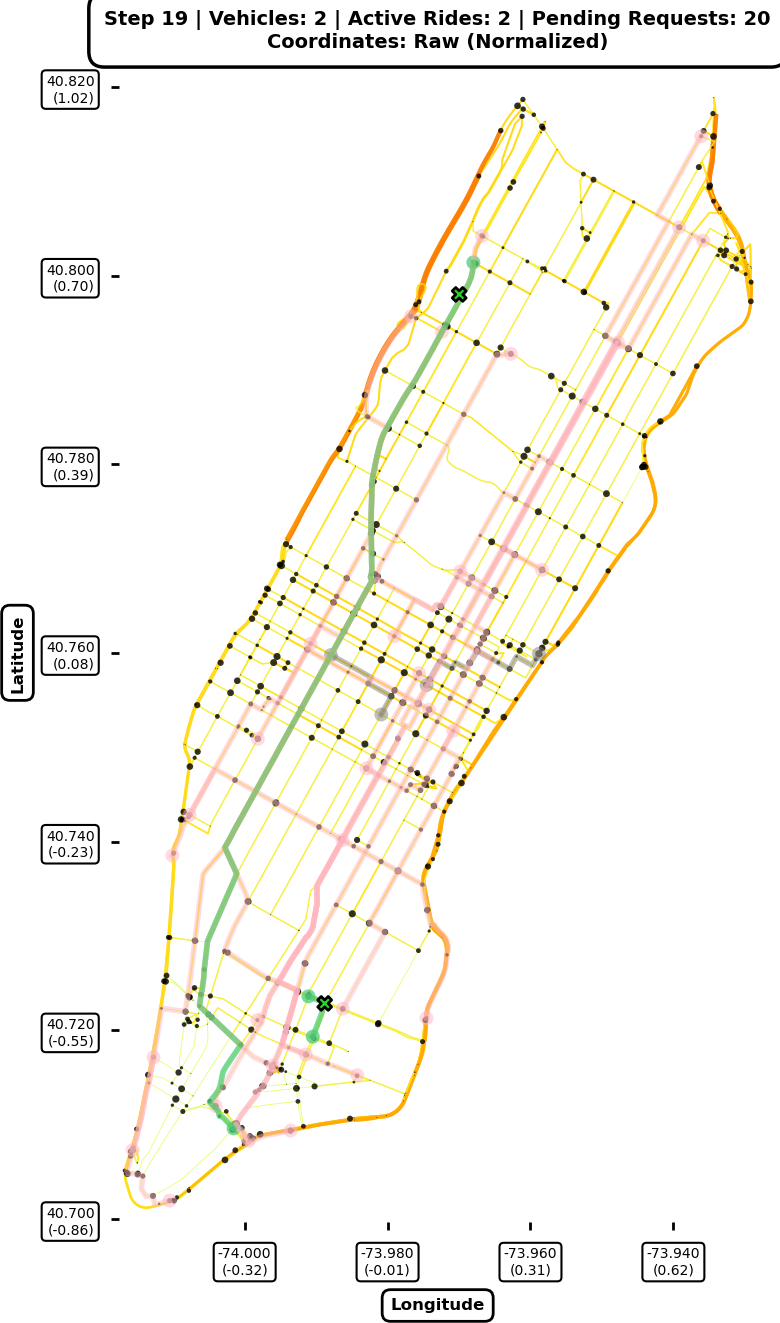

In [304]:
fig, ax = env.render()
fig

In [305]:
z = 2 / 2 - 1
arr = 1 / (1 + np.exp(-z))

In [306]:
z, arr

(0.0, np.float64(0.5))